In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

sns.set() 

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12, 6 
plt.rcParams['font.size'] = 14 
plt.rcParams['axes.unicode_minus'] = False 

# 결측치 시각화를 위한 라이브러리
import missingno 

# 데이터 전처리 알고리즘 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler 

# 학습용과 검증용으로 나누는  함수 
from sklearn.model_selection import train_test_split 

# 교차검증 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한도구 
from sklearn.model_selection import GridSearchCV 

# 머신러닝 알고리즘 - 분류 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from lightgbm import LGBMClassifier 
from xgboost import XGBClassifier 
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀 
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet 
from sklearn.svm import SVR 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor 
from sklearn.ensemble import GradientBoostingRegressor 
from lightgbm import LGBMRegressor 
from xgboost import XGBRegressor 
from sklearn.ensemble import VotingRegressor 

# 학습 모델 저장을 위한 라이브러리
import pickle 

In [54]:
true_label = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\PCA안한데이터\Segment\Segment.csv")
predicted_label = pd.read_csv(r"C:\Users\SAMSUNG\OneDrive\바탕 화면\학습완료\혼동계수용train예측.csv")

In [55]:
true_label 

,기준년월,ID,Segment
0,201807,TRAIN_000000,D
1,201807,TRAIN_000001,E
2,201807,TRAIN_000002,C
3,201807,TRAIN_000003,D
4,201807,TRAIN_000004,E
...,...,...,...
2399995,201812,TRAIN_399995,E
2399996,201812,TRAIN_399996,D
2399997,201812,TRAIN_399997,C
2399998,201812,TRAIN_399998,E


In [56]:
predicted_label

,ID,기준년월,Segment
0,TRAIN_000000,201807,E
1,TRAIN_000001,201807,E
2,TRAIN_000002,201807,C
3,TRAIN_000003,201807,D
4,TRAIN_000004,201807,E
...,...,...,...
2399995,TRAIN_399995,201812,E
2399996,TRAIN_399996,201812,E
2399997,TRAIN_399997,201812,E
2399998,TRAIN_399998,201812,E


In [57]:
true_label = true_label[['ID', '기준년월', 'Segment']]

In [63]:

true_label = true_label[true_label['기준년월'] == 201812]
true_label


,ID,기준년월,Segment
2000000,TRAIN_000000,201812,D
2000001,TRAIN_000001,201812,E
2000002,TRAIN_000002,201812,C
2000003,TRAIN_000003,201812,D
2000004,TRAIN_000004,201812,E
...,...,...,...
2399995,TRAIN_399995,201812,E
2399996,TRAIN_399996,201812,D
2399997,TRAIN_399997,201812,C
2399998,TRAIN_399998,201812,E


In [59]:
predicted_label = predicted_label[predicted_label['기준년월'] == 201812]
predicted_label

,ID,기준년월,Segment
2000000,TRAIN_000000,201812,D
2000001,TRAIN_000001,201812,E
2000002,TRAIN_000002,201812,E
2000003,TRAIN_000003,201812,D
2000004,TRAIN_000004,201812,E
...,...,...,...
2399995,TRAIN_399995,201812,E
2399996,TRAIN_399996,201812,E
2399997,TRAIN_399997,201812,E
2399998,TRAIN_399998,201812,E


In [60]:
true_label

,ID,기준년월,Segment
2000000,TRAIN_000000,201812,D
2000001,TRAIN_000001,201812,E
2000002,TRAIN_000002,201812,C
2000003,TRAIN_000003,201812,D
2000004,TRAIN_000004,201812,E
...,...,...,...
2399995,TRAIN_399995,201812,E
2399996,TRAIN_399996,201812,D
2399997,TRAIN_399997,201812,C
2399998,TRAIN_399998,201812,E


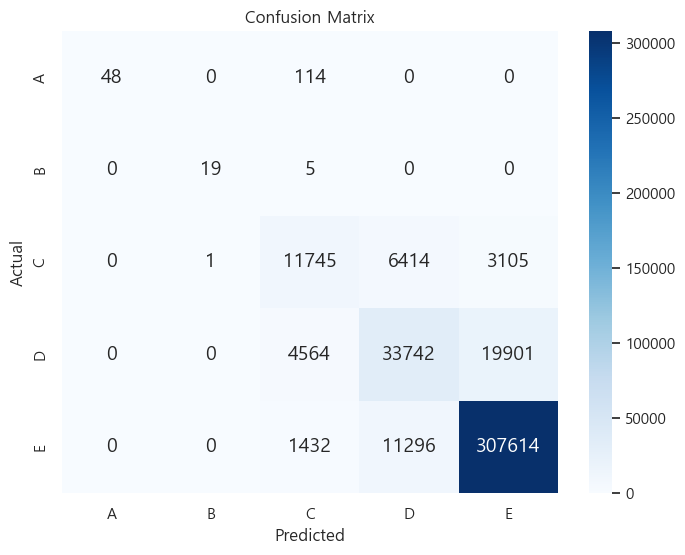

In [64]:
from sklearn.metrics import confusion_matrix

# 1. 혼동 행렬 계산
cm = confusion_matrix(true_label['Segment'], predicted_label['Segment'], labels=['A', 'B', 'C', 'D', 'E'])

# 2. 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A', 'B', 'C', 'D', 'E'], yticklabels=['A', 'B', 'C', 'D', 'E'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [65]:
from sklearn.metrics import classification_report
# 3. 정밀도, 재현율, F1-score 출력
print(classification_report(true_label['Segment'], predicted_label['Segment'], labels=['A', 'B', 'C', 'D', 'E']))

              precision    recall  f1-score   support

           A       1.00      0.30      0.46       162
           B       0.95      0.79      0.86        24
           C       0.66      0.55      0.60     21265
           D       0.66      0.58      0.62     58207
           E       0.93      0.96      0.95    320342

    accuracy                           0.88    400000
   macro avg       0.84      0.64      0.70    400000
weighted avg       0.88      0.88      0.88    400000

